In [18]:
import pandas as pd, xarray as xr

df = pd.read_csv('/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/data/SOCATv2025_SO_clean.csv', low_memory=False)

bioregions = xr.load_dataset("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/data/bioregions.nc")

/tmp/ipykernel_2406231/1430010718.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", n_colors)


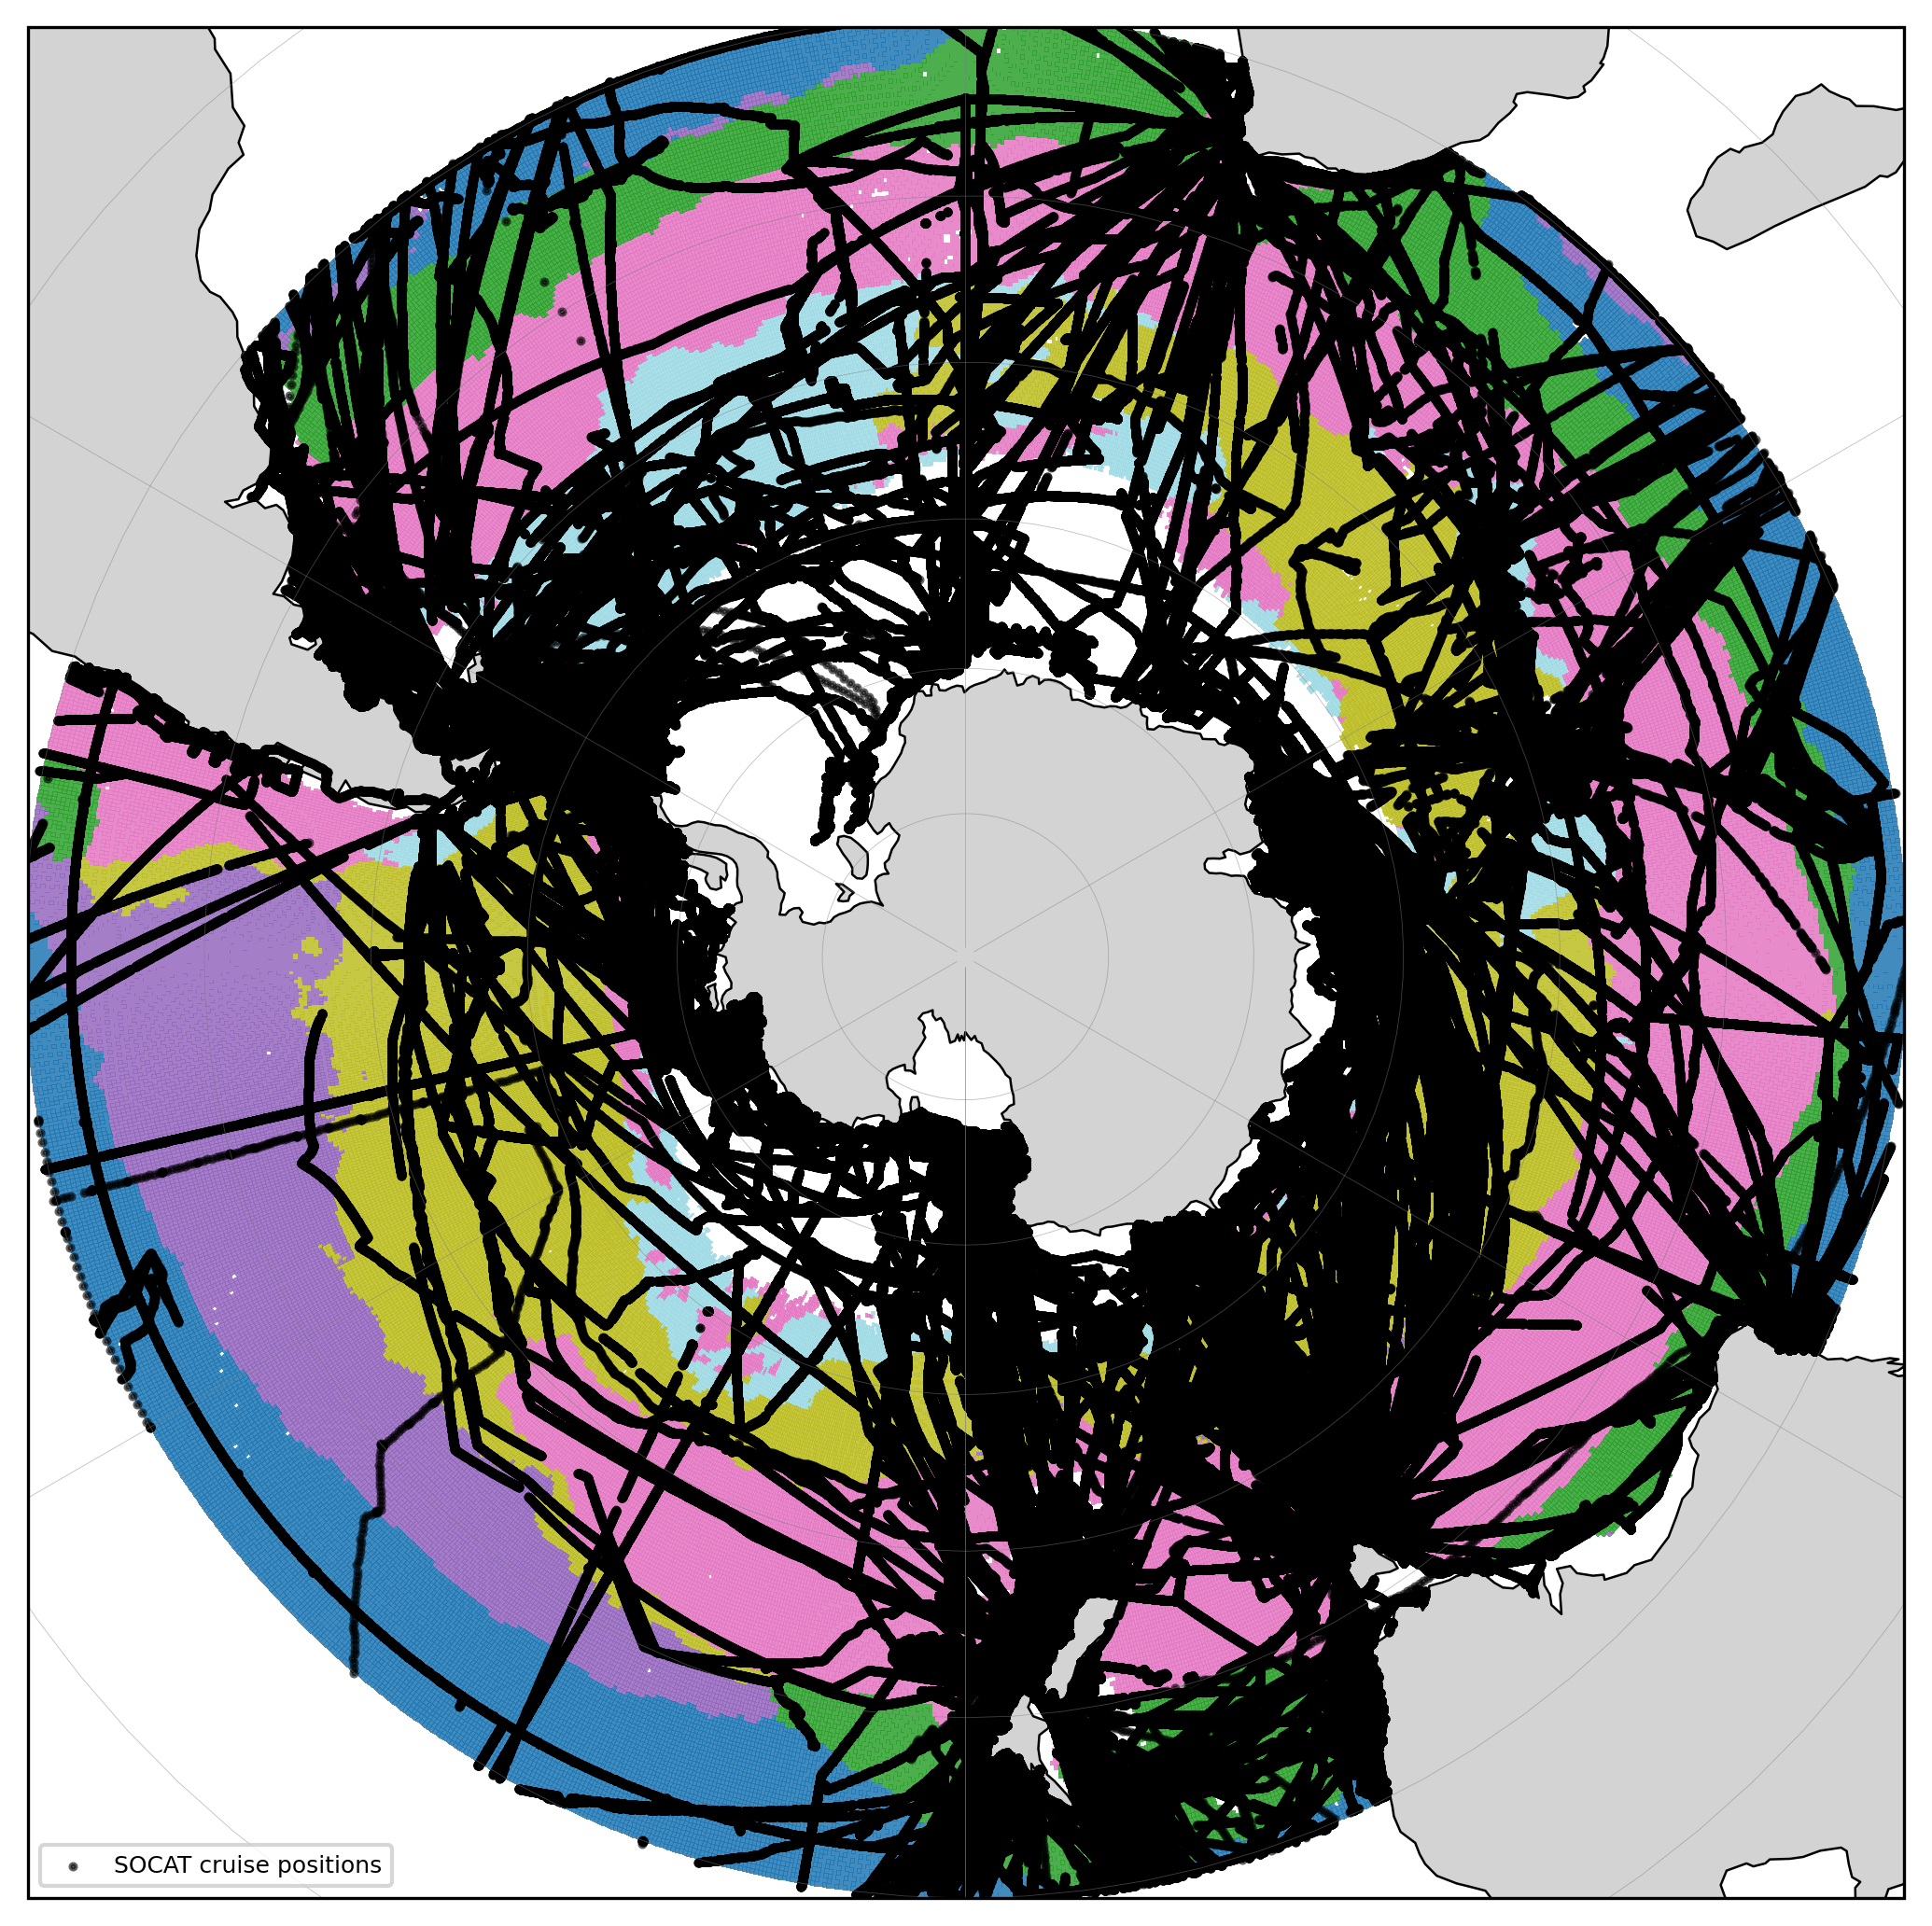

In [4]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# bioregions = loaded xarray dataset
# It contains: bioregions["cluster"], bioregions["latitude"], bioregions["longitude"]

# Extract variables
clusters = bioregions["cluster"].values
lats = bioregions["latitude"].values
lons = bioregions["longitude"].values

# ---- SET UP MAP ----
fig = plt.figure(figsize=(7, 7), dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

# Base map
ax.coastlines(resolution='110m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.5)

# ---- ADD BIOREGIONS (categorical map) ----
# Define a discrete colormap
unique_vals = np.unique(clusters[~np.isnan(clusters)]).astype(int)
n_colors = len(unique_vals)
cmap = plt.cm.get_cmap("tab20", n_colors)

# Create a normalization mapping each cluster to a color class
norm = mcolors.BoundaryNorm(boundaries=np.arange(n_colors+1)-0.5, ncolors=n_colors)

# Plot raster grid
mesh = ax.pcolormesh(
    lons,
    lats,
    clusters,
    cmap=cmap,
    norm=norm,
    shading="nearest",
    transform=ccrs.PlateCarree(),
    zorder=1,     # underneath SOCAT points
    alpha=0.85
)

# ---- SCATTER SOCAT CRUISE POSITIONS ----
ax.scatter(
    df["longitude"],
    df["latitude"],
    s=2,
    color="k",
    transform=ccrs.PlateCarree(),
    alpha=0.6,
    label="SOCAT cruise positions",
    zorder=2
)

# Legend
ax.legend(
    loc='lower left',
    fontsize=6,
    frameon=True
)

plt.tight_layout()
plt.show()


In [5]:
# ===============================================================
# Assign Southern Hemisphere seasons based on month
# ===============================================================

def classify_season(month):
    if month in [6, 7, 8]:
        return "winter"     # JJA
    elif month in [9, 10, 11]:
        return "spring"     # SON
    elif month in [12, 1, 2]:
        return "summer"     # DJF
    elif month in [3, 4, 5]:
        return "autumn"     # MAM
    return None

df["season"] = df["month"].apply(classify_season)

# ===============================================================
# Build helper table: earliest year per expocode 
# ===============================================================

df_years = (
    df.groupby("expocode")["year"]
      .min()
      .reset_index(name="year")
)

# ===============================================================
# Build Winter Cruise DataFrame
# ===============================================================

df_winter = df[df["season"] == "winter"]

df_winter_cruises = (
    df_winter
    .groupby("expocode")
    .size()
    .reset_index(name="n_points")
    .merge(df_years, on="expocode", how="left")
    .sort_values(["n_points", "year"], ascending=[False, True])
    .reset_index(drop=True)
)

# ===============================================================
# Build Spring Cruise DataFrame
# ===============================================================

df_spring = df[df["season"] == "spring"]

df_spring_cruises = (
    df_spring
    .groupby("expocode")
    .size()
    .reset_index(name="n_points")
    .merge(df_years, on="expocode", how="left")
    .sort_values(["n_points", "year"], ascending=[False, True])
    .reset_index(drop=True)
)



In [6]:
pd.set_option("display.max_rows", None)      # show all rows
pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.width", None)         # no line wrapping
pd.set_option("display.max_colwidth", None)  # don't shorten column text

display(df_spring_cruises)


,expocode,n_points,year
0,09AR20120914,57897,2012
1,09AR20110222,32549,2011
2,09AR20011031,32128,2001
3,09AR20151028,29904,2015
4,320620010907,29625,2001
5,09AR20181025,29418,2018
6,096U20181017,25543,2018
7,09AR20191025,24357,2019
8,09AR20161026,23041,2016
9,61TG20151028,23027,2015


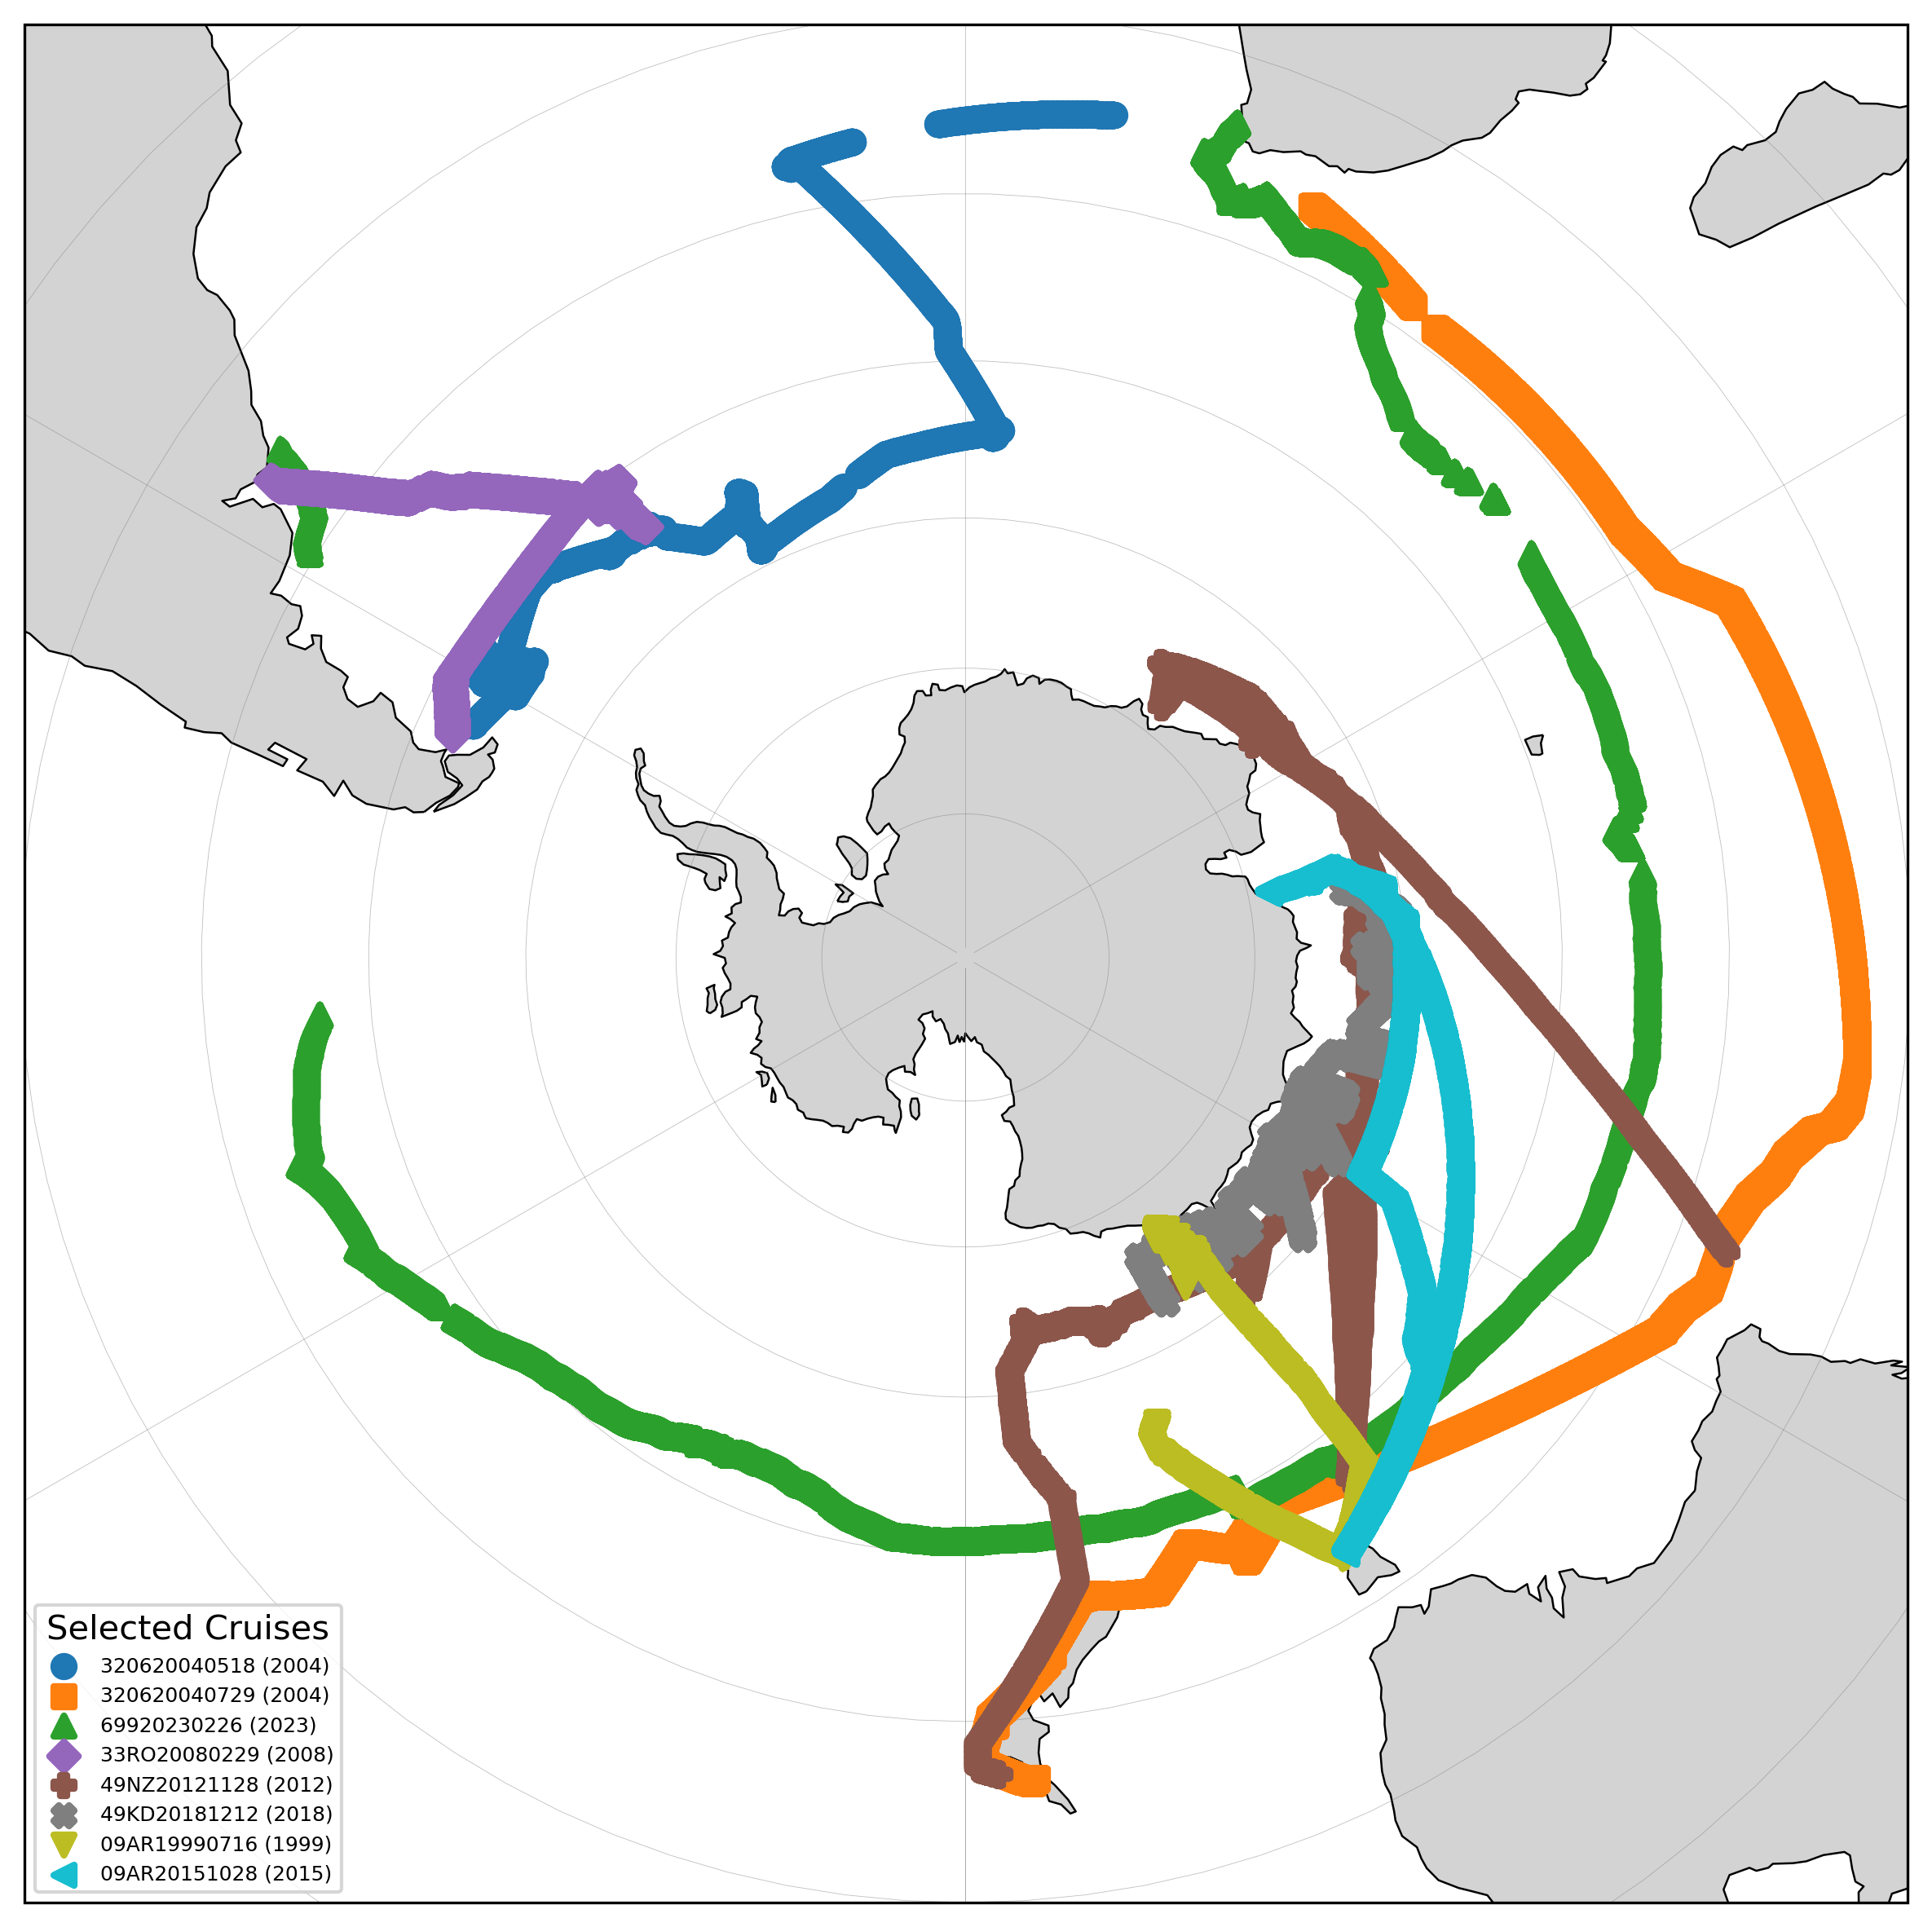

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# ===============================================================
# 1. Select ONLY the cruises you want
# ===============================================================

keep_expocodes = [
    "320620040518",
    "320620040729",
    "69920230226",
    "33RO20080229",
    "49NZ20121128",
    "49KD20181212",
    "09AR19990716",
    "09AR20151028"
]

df_sel = df[df["expocode"].isin(keep_expocodes)]

# ===============================================================
# 2. Extract bioregion raster
# ===============================================================

clusters = bioregions["cluster"].values
lats = bioregions["latitude"].values
lons = bioregions["longitude"].values

# ===============================================================
# 3. PLOT
# ===============================================================

fig = plt.figure(figsize=(8, 8), dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

# Base map
ax.coastlines(resolution="110m", linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.gridlines(draw_labels=False, linewidth=0.2, color="gray", alpha=0.5)

# Bioregion background
unique_vals = np.unique(clusters[~np.isnan(clusters)]).astype(int)
base_cmap = plt.get_cmap("tab20")
colors_list = base_cmap(np.linspace(0, 1, len(unique_vals)))
cmap = mcolors.ListedColormap(colors_list)
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(len(unique_vals)+1) - 0.5,
    ncolors=len(unique_vals)
)

# ax.pcolormesh(
#     lons, lats, clusters,
#     cmap=cmap, norm=norm,
#     shading="nearest",
#     transform=ccrs.PlateCarree(),
#     zorder=1,
#     alpha=0.85
# )

# ===============================================================
# 4. Plot each cruise with its own unique color + marker
# ===============================================================

# Colors and markers to cycle through
colors = plt.cm.tab10(np.linspace(0, 1, len(keep_expocodes)))
markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]  # enough for many cruises

for i, exp in enumerate(keep_expocodes):
    df_c = df_sel[df_sel["expocode"] == exp]

    if df_c.empty:
        print(f"⚠️ No data for {exp} — skipping.")
        continue

    # Safely extract year
    year_val = df_c["year"].min()
    year = int(year_val) if not np.isnan(year_val) else None
    year_str = year if year is not None else "unknown"

    ax.scatter(
        df_c["longitude"],
        df_c["latitude"],
        transform=ccrs.PlateCarree(),
        linewidth=2,
        color=colors[i],
        marker=markers[i % len(markers)],
        # markersize=3,
        label=f"{exp} ({year_str})",
        zorder=3
    )

# Legend
ax.legend(
    loc="lower left",
    fontsize=6,
    title="Selected Cruises",
    frameon=True
)

plt.tight_layout()
plt.show()


In [39]:
# 1. Count points per expocode
counts = df_sel.groupby("expocode").size().rename("n_points")

# 2. Unique expocode list (one row per cruise)
df_sel_unique = (
    df_sel.drop_duplicates(subset="expocode")
          .sort_values(by="year")
          .merge(counts, on="expocode", how="left")
)

df_sel_unique


,expocode,year,month,day,hour,minute,second,longitude,latitude,fco2_rec,sample_depth_m,salinity,sst_degC,pressure_hpa,season,n_points
0,69920230226,2023,2,26,16,36,38.0,18.03574,-33.61358,371.536,NaN,34.235,21.127,NaN,summer,34541
